In [1]:
import numpy as np
import matplotlib.pylab as plt

In [2]:
#D108 - day15 DKO
#D110 - day15 WT
#D118 - day0 WT

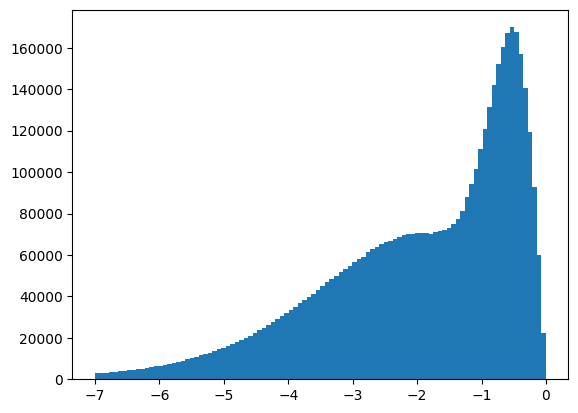

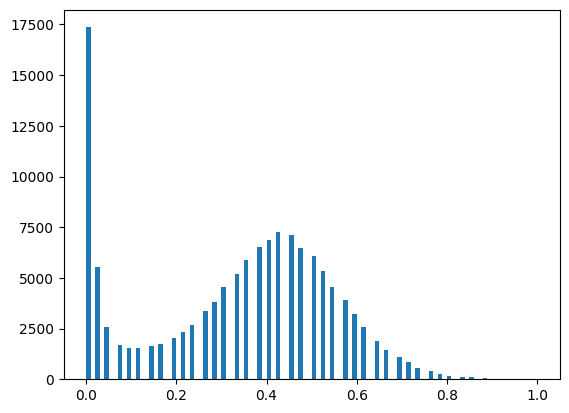

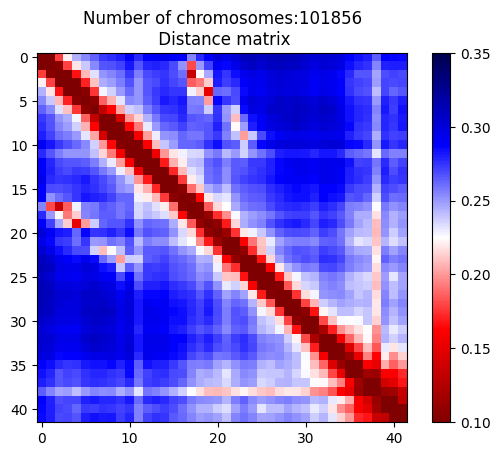

In [3]:
dic = np.load(r"C:\Users\Carlos\Desktop\Myh67_scripts\D118_traces_info.npz")#,zxys_fs=zxys_fs,score=score,icells_CMS=icells_CMS,th67=[th6,th7])
zxys_fs = dic['zxys_fs']
score = dic['score']
#icells_CMS = dic['icells_CMS']
icells = zxys_fs[:,0,-3]
score_ = score[~np.isnan(score)]
score_=score_[score_>-7]
plt.figure()
plt.hist(score_,bins=100);

X = zxys_fs[:,:,:3].copy()
X[score<-1.]=np.nan
fr = np.mean(~np.isnan(X[:,:,0]),axis=-1)
plt.figure()
plt.hist(fr,bins=100);
keep = (fr>0.1)#&np.in1d(icells,icells_CMS)
from scipy.spatial.distance import pdist,squareform
mats = np.array([squareform(pdist(X_)) for X_ in X[keep]])
mats_D118 = mats
plt.figure()
plt.title("Number of chromosomes:"+str(len(mats))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats,axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

In [4]:
zxys_fs[:,0,-4]

array([0.54334996, 0.18035353, 0.43212088, ..., 0.32977779, 0.04941407,
       0.00268486])

C:\Users\carlos\AppData\Local\Temp\ipykernel_18304\4199667947.py:26: RuntimeWarning: divide by zero encountered in log
  H7,H6 = np.log(zxys_fs[keep,0,-2]),np.log(zxys_fs[keep,0,-3])
C:\Users\carlos\anaconda3\envs\cellpose2\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


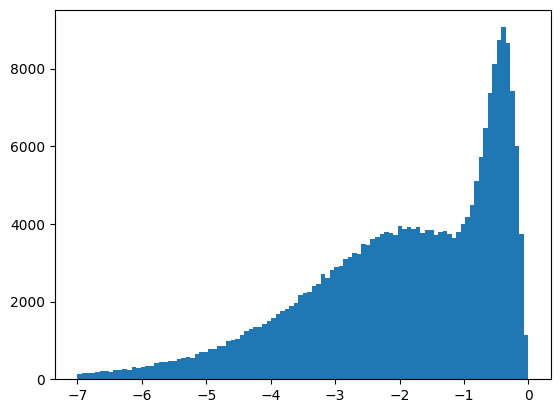

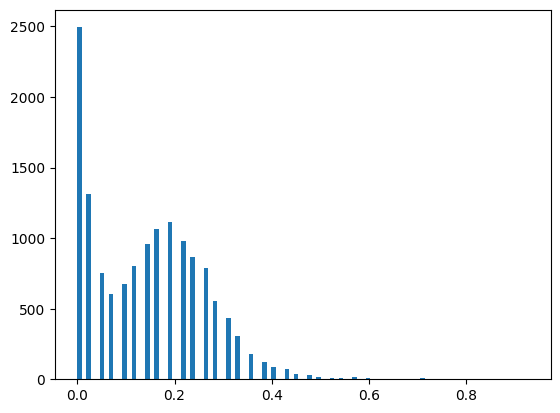

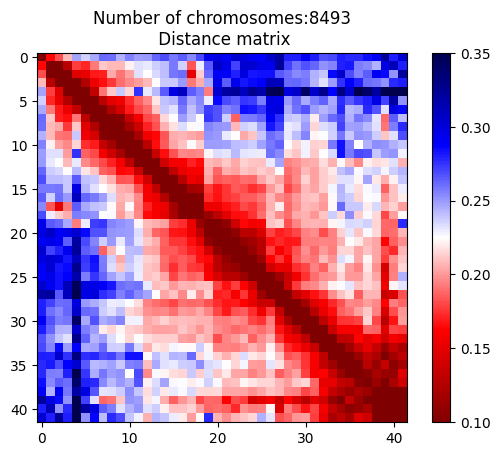

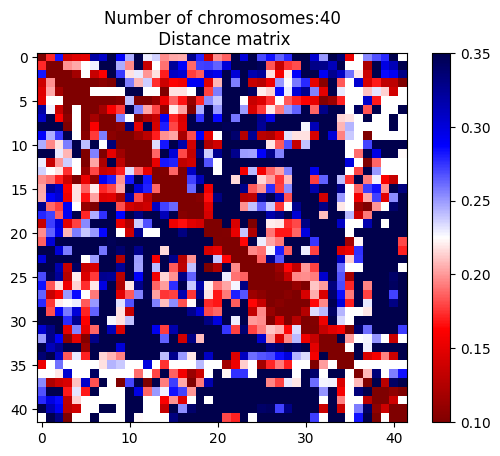

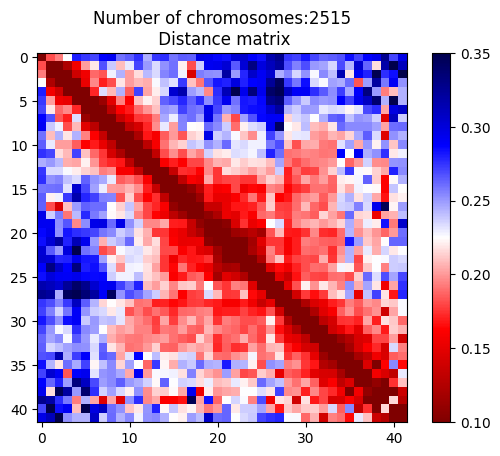

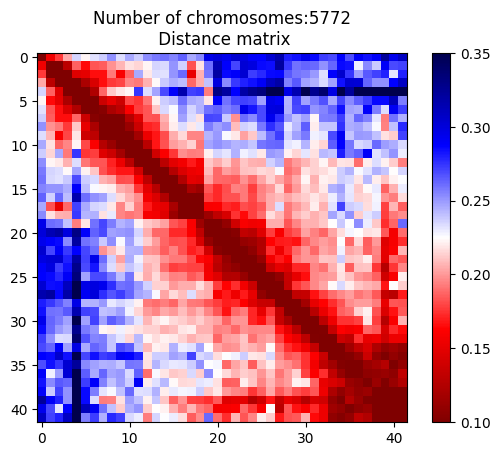

In [5]:
dic = np.load(r"C:\Users\Carlos\Desktop\Myh67_scripts\D103_traces_info.npz")#,zxys_fs=zxys_fs,score=score,icells_CMS=icells_CMS,th67=[th6,th7])
zxys_fs = dic['zxys_fs']
score = dic['score']
#icells_CMS = dic['icells_CMS']
icells = zxys_fs[:,0,-4]
score_ = score[~np.isnan(score)]
score_=score_[score_>-7]
th6, th7 = dic['th67']
plt.figure()
plt.hist(score_,bins=100);

X = zxys_fs[:,:,:3].copy()
X[score<-1.]=np.nan
fr = np.mean(~np.isnan(X[:,:,0]),axis=-1)
plt.figure()
plt.hist(fr,bins=100);
keep = (fr>0.1)#&np.in1d(icells,icells_CMS)
from scipy.spatial.distance import pdist,squareform
mats = np.array([squareform(pdist(X_)) for X_ in X[keep]])
mats_D120 = mats
plt.figure()
plt.title("Number of chromosomes:"+str(len(mats))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats,axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

H7,H6 = np.log(zxys_fs[keep,0,-2]),np.log(zxys_fs[keep,0,-3])
# th7,th6 =10.5, 11
keep7 = (H7>th7)&(H6<th6)
keep6 = (H6>th6)&(H7<th7)
keepN = (H6<th6)&(H7<th7)

plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keep7]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D120[keep7],axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()


plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keep6]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D120[keep6],axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keepN]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D120[keepN],axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

C:\Users\carlos\anaconda3\envs\cellpose2\lib\site-packages\numpy\lib\nanfunctions.py:1095: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanmedian1d, axis, a, overwrite_input)


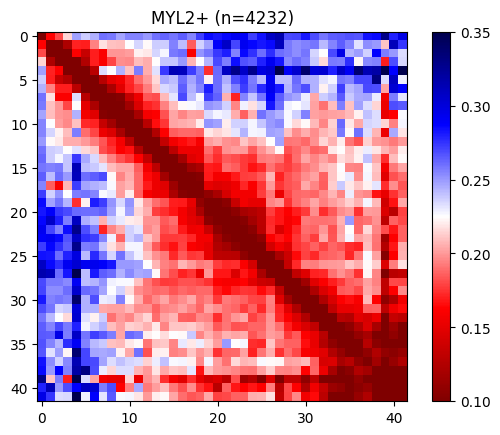

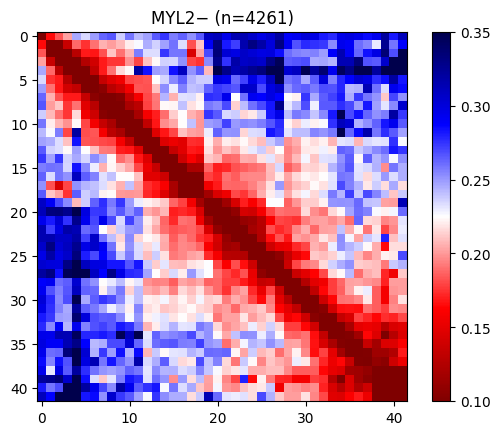

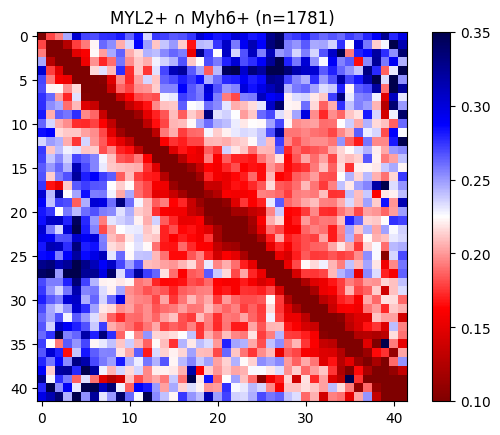

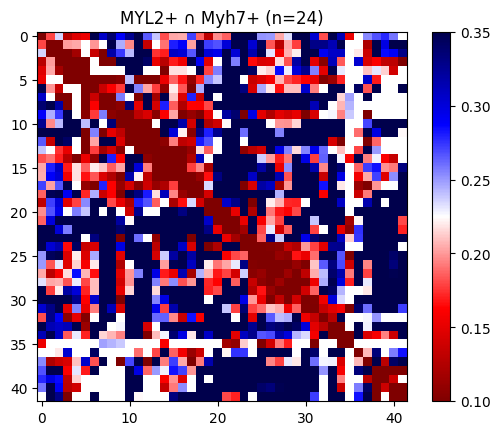

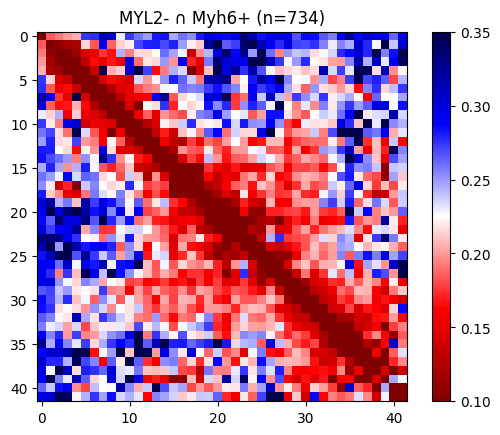

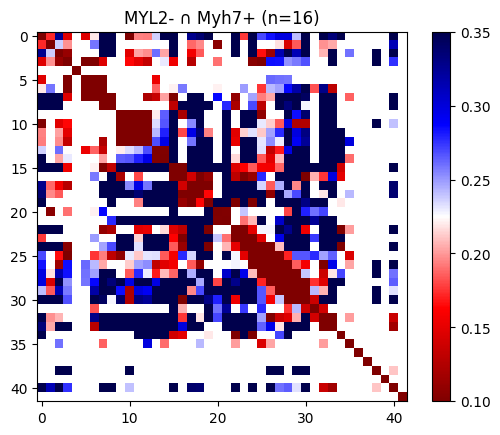

In [6]:
# Step 1: Get MYL2+ mask (assuming flag stored at last position)
is_MYL2 = zxys_fs[keep, 0, -1] == 1
is_not_MYL2 = zxys_fs[keep, 0, -1] == 0

# H6, H7 already defined as log intensities
is_H6_pos = H6 > th6
is_H7_pos = H7 > th7

# Step 3: Define combinations
keep_myl2 = is_MYL2
keep_nonmyl2 = is_not_MYL2
keep_myl2_myh6 = is_MYL2 & is_H6_pos & ~is_H7_pos
keep_myl2_myh7 = is_MYL2 & is_H7_pos & ~is_H6_pos
keep_nonmyl2_myh6 = (~is_MYL2) & is_H6_pos & ~is_H7_pos
keep_nonmyl2_myh7 = (~is_MYL2) & is_H7_pos & ~is_H6_pos

# Step 4: Compute matrices
mats_D120_myl2     = mats_D120[keep_myl2]
mats_D120_nonmyl2  = mats_D120[keep_nonmyl2]
mats_D120_myl2_h6  = mats_D120[keep_myl2_myh6]
mats_D120_myl2_h7  = mats_D120[keep_myl2_myh7]
mats_D120_nonmyl2_h6  = mats_D120[keep_nonmyl2_myh6]
mats_D120_nonmyl2_h7  = mats_D120[keep_nonmyl2_myh7]

# Step 5: Plot
plt.figure()
plt.title(f"MYL2+ (n={len(mats_D120_myl2)})")
plt.imshow(np.nanmedian(mats_D120_myl2, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2− (n={len(mats_D120_nonmyl2)})")
plt.imshow(np.nanmedian(mats_D120_nonmyl2, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2+ ∩ Myh6+ (n={len(mats_D120_myl2_h6)})")
plt.imshow(np.nanmedian(mats_D120_myl2_h6, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2+ ∩ Myh7+ (n={len(mats_D120_myl2_h7)})")
plt.imshow(np.nanmedian(mats_D120_myl2_h7, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2- ∩ Myh6+ (n={len(mats_D120_nonmyl2_h6)})")
plt.imshow(np.nanmedian(mats_D120_nonmyl2_h6, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2- ∩ Myh7+ (n={len(mats_D120_nonmyl2_h7)})")
plt.imshow(np.nanmedian(mats_D120_nonmyl2_h7, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

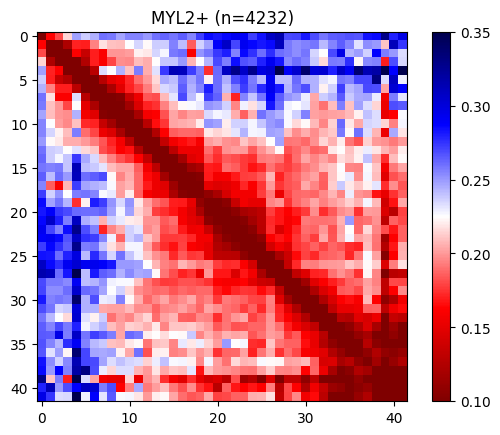

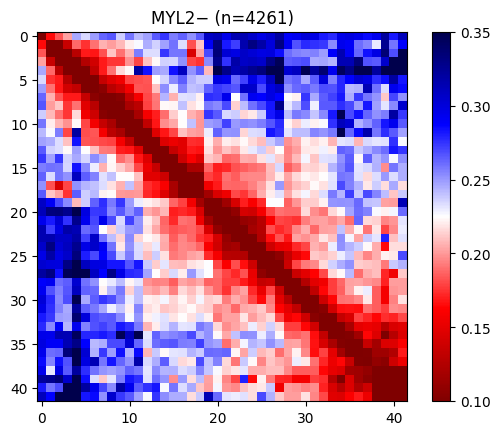

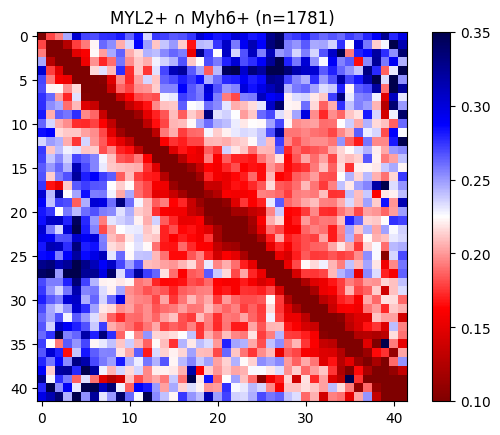

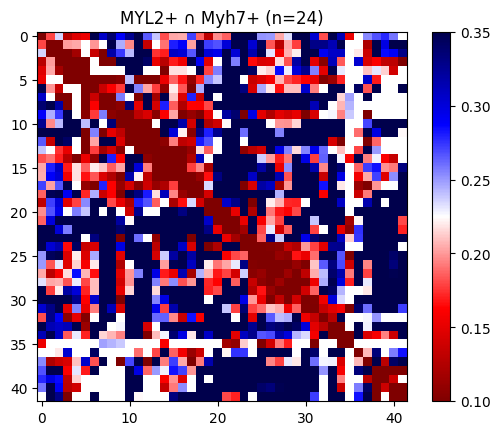

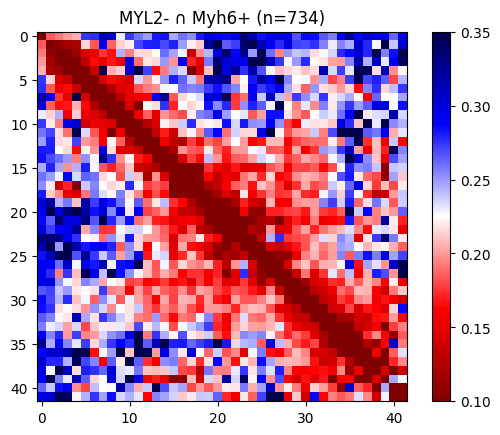

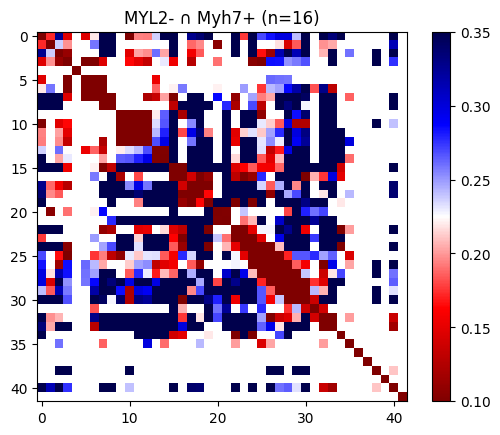

In [7]:
# Step 1: Get MYL2+ mask (assuming flag stored at last position)
is_MYL2 = zxys_fs[keep, 0, -1] == 1
is_not_MYL2 = zxys_fs[keep, 0, -1] == 0

# H6, H7 already defined as log intensities
is_H6_pos = H6 > th6
is_H7_pos = H7 > th7

# Step 3: Define combinations
keep_myl2 = is_MYL2
keep_nonmyl2 = is_not_MYL2
keep_myl2_myh6 = is_MYL2 & is_H6_pos & ~is_H7_pos
keep_myl2_myh7 = is_MYL2 & is_H7_pos & ~is_H6_pos
keep_nonmyl2_myh6 = (~is_MYL2) & is_H6_pos & ~is_H7_pos
keep_nonmyl2_myh7 = (~is_MYL2) & is_H7_pos & ~is_H6_pos

# Step 4: Compute matrices
mats_D120_myl2     = mats_D120[keep_myl2]
mats_D120_nonmyl2  = mats_D120[keep_nonmyl2]
mats_D120_myl2_h6  = mats_D120[keep_myl2_myh6]
mats_D120_myl2_h7  = mats_D120[keep_myl2_myh7]
mats_D120_nonmyl2_h6  = mats_D120[keep_nonmyl2_myh6]
mats_D120_nonmyl2_h7  = mats_D120[keep_nonmyl2_myh7]

# Step 5: Plot
plt.figure()
plt.title(f"MYL2+ (n={len(mats_D120_myl2)})")
plt.imshow(np.nanmedian(mats_D120_myl2, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2− (n={len(mats_D120_nonmyl2)})")
plt.imshow(np.nanmedian(mats_D120_nonmyl2, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2+ ∩ Myh6+ (n={len(mats_D120_myl2_h6)})")
plt.imshow(np.nanmedian(mats_D120_myl2_h6, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2+ ∩ Myh7+ (n={len(mats_D120_myl2_h7)})")
plt.imshow(np.nanmedian(mats_D120_myl2_h7, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2- ∩ Myh6+ (n={len(mats_D120_nonmyl2_h6)})")
plt.imshow(np.nanmedian(mats_D120_nonmyl2_h6, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2- ∩ Myh7+ (n={len(mats_D120_nonmyl2_h7)})")
plt.imshow(np.nanmedian(mats_D120_nonmyl2_h7, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

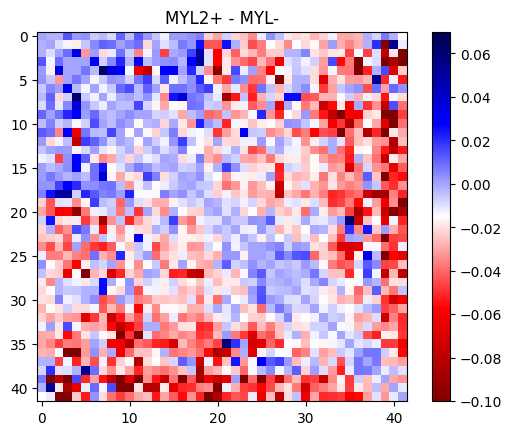

In [8]:
plt.figure()
plt.title(f"MYL2+ - MYL-")
plt.imshow(np.nanmedian(mats_D120_myl2, axis=0)-np.nanmedian(mats_D120_nonmyl2, axis=0), cmap='seismic_r', vmin=-0.1, vmax=0.07)
plt.colorbar()

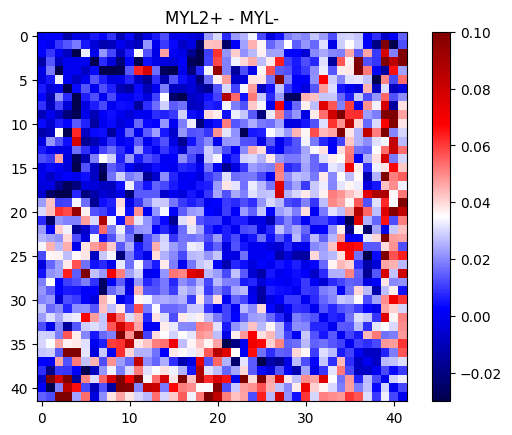

In [9]:
plt.figure()
plt.title(f"MYL2+ - MYL-")
plt.imshow(np.nanmedian(mats_D120_nonmyl2, axis=0)-np.nanmedian(mats_D120_myl2, axis=0), cmap='seismic', vmin=-0.03, vmax=0.1)
plt.colorbar()

In [10]:
med_D120 = np.nanmedian(mats_D120,axis=0)


C:\Users\carlos\AppData\Local\Temp\ipykernel_18304\3671604749.py:26: RuntimeWarning: divide by zero encountered in log
  H7,H6 = np.log(zxys_fs[keep,0,-2]),np.log(zxys_fs[keep,0,-3])


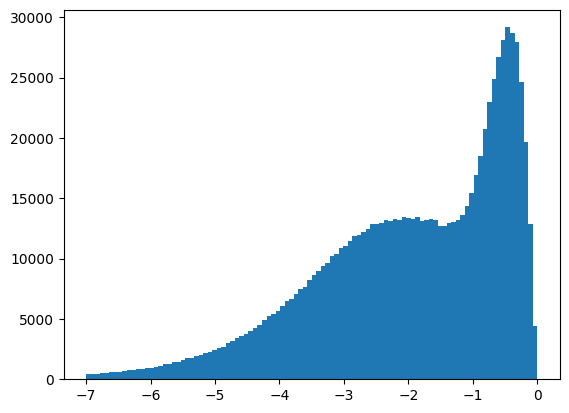

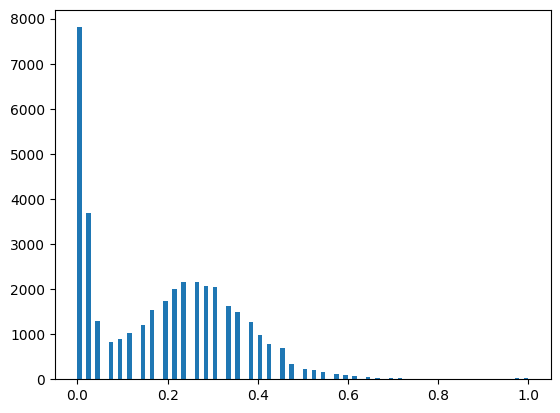

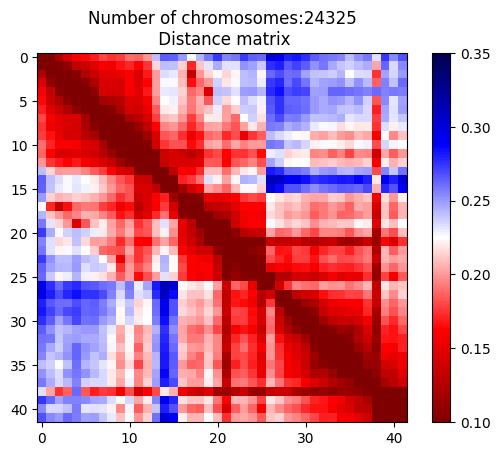

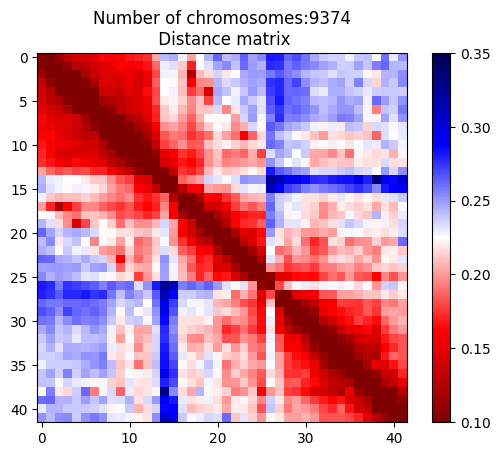

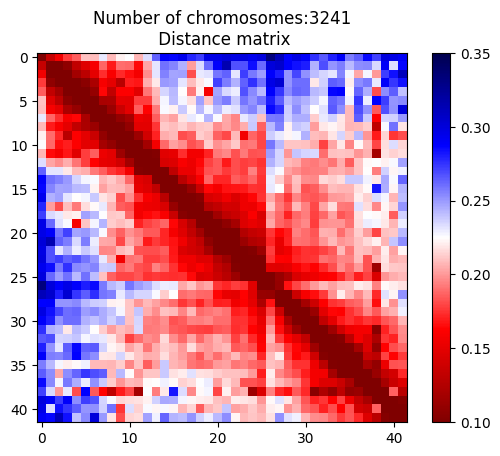

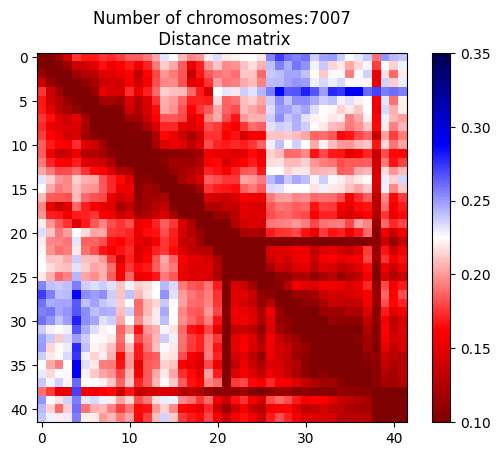

In [11]:
dic = np.load(r"C:\Users\Carlos\Desktop\Myh67_scripts\D104_traces_info.npz")#,zxys_fs=zxys_fs,score=score,icells_CMS=icells_CMS,th67=[th6,th7])
zxys_fs = dic['zxys_fs']
score = dic['score']
#icells_CMS = dic['icells_CMS']
icells = zxys_fs[:,0,-4]
score_ = score[~np.isnan(score)]
score_=score_[score_>-7]
th6, th7 = dic['th67']
plt.figure()
plt.hist(score_,bins=100);

X = zxys_fs[:,:,:3].copy()
X[score<-1.]=np.nan
fr = np.mean(~np.isnan(X[:,:,0]),axis=-1)
plt.figure()
plt.hist(fr,bins=100);
keep = (fr>0.1)#&np.in1d(icells,icells_CMS)
from scipy.spatial.distance import pdist,squareform
mats = np.array([squareform(pdist(X_)) for X_ in X[keep]])
mats_D104 = mats
plt.figure()
plt.title("Number of chromosomes:"+str(len(mats))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats,axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

H7,H6 = np.log(zxys_fs[keep,0,-2]),np.log(zxys_fs[keep,0,-3])
# th7,th6 =10.5, 11
keep7 = (H7>th7)&(H6<th6)
keep6 = (H6>th6)&(H7<th7)
keepN = (H6<th6)&(H7<th7)

plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keep7]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D104[keep7],axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()


plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keep6]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D104[keep6],axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keepN]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D104[keepN],axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

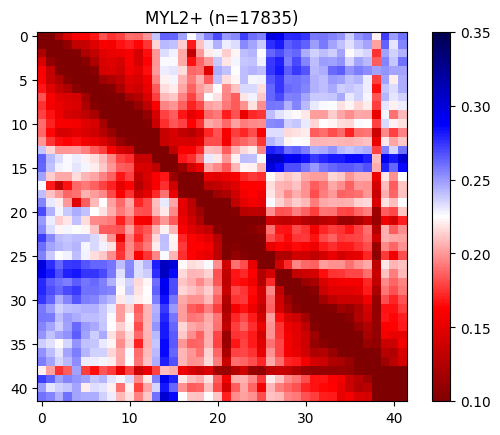

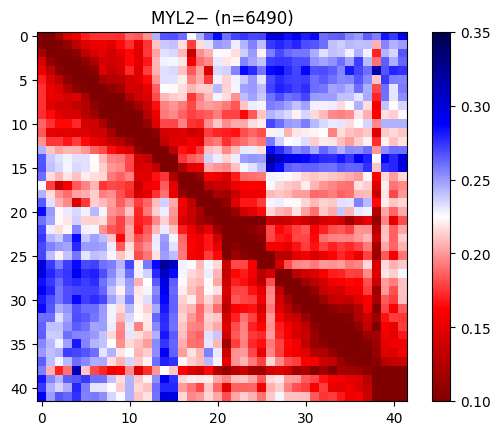

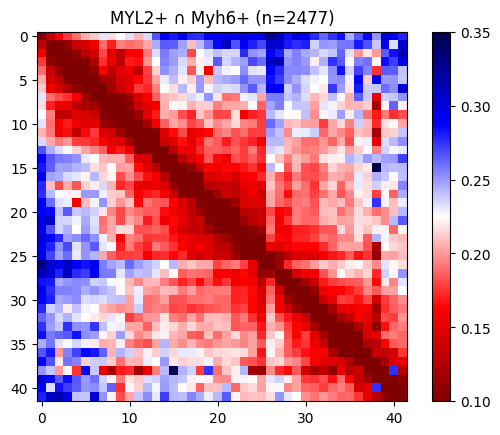

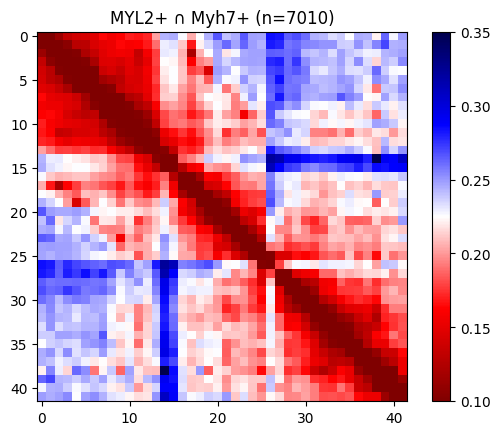

In [12]:
# Step 1: Get MYL2+ mask (assuming flag stored at last position)
is_MYL2 = zxys_fs[keep, 0, -1] == 1
is_not_MYL2 = zxys_fs[keep, 0, -1] == 0

# Step 2: Use already-defined H6, H7 and keep masks
# H6, H7 already defined as log intensities
is_H6_pos = H6 > th6
is_H7_pos = H7 > th7

# Step 3: Define combinations
keep_myl2 = is_MYL2
keep_nonmyl2 = is_not_MYL2
keep_myl2_myh6 = is_MYL2 & is_H6_pos & ~is_H7_pos
keep_myl2_myh7 = is_MYL2 & is_H7_pos & ~is_H6_pos

# Step 4: Compute matrices
mats_D104_myl2     = mats_D104[keep_myl2]
mats_D104_nonmyl2  = mats_D104[keep_nonmyl2]
mats_D104_myl2_h6  = mats_D104[keep_myl2_myh6]
mats_D104_myl2_h7  = mats_D104[keep_myl2_myh7]

# Step 5: Plot
plt.figure()
plt.title(f"MYL2+ (n={len(mats_D104_myl2)})")
plt.imshow(np.nanmedian(mats_D104_myl2, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2− (n={len(mats_D104_nonmyl2)})")
plt.imshow(np.nanmedian(mats_D104_nonmyl2, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2+ ∩ Myh6+ (n={len(mats_D104_myl2_h6)})")
plt.imshow(np.nanmedian(mats_D104_myl2_h6, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2+ ∩ Myh7+ (n={len(mats_D104_myl2_h7)})")
plt.imshow(np.nanmedian(mats_D104_myl2_h7, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

In [ ]:

med_D104 = np.nanmedian(mats_D104,axis=0)
med_D118 = np.nanmedian(mats_D118,axis=0)
med_D104_keep7 = np.nanmedian(mats_D104[keep7],axis=0)
med_D104_keep6 = np.nanmedian(mats_D104[keep6],axis=0)
med_D104_keepN = np.nanmedian(mats_D104[keepN],axis=0)

In [ ]:
data = [med_D120_keep.ravel()/med_D104_keep7.ravel(),med_D120_keep.ravel()/med_D104_keep6.ravel(),med_D120_keep.ravel()/med_D104_keepN.ravel(),med_D120_keep.ravel()/med_D118.ravel()]
data = [d[~np.isnan(d)]for d in data]

In [ ]:
data = np.abs([med_D120_keep.ravel()-med_D104_keep7.ravel(),med_D120_keep.ravel()-med_D104_keep6.ravel(),med_D120_keep.ravel()-med_D104_keepN.ravel(),med_D120_keep.ravel()-med_D118.ravel()])
data = [d[~np.isnan(d)]for d in data]
bp = plt.boxplot([d for d in data], patch_artist=True, showfliers=False,whis=[15,85],notch=True,)

# Define the colors for each box
colors = ['green','red', 'black', 'gray']

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
plt.plot([0,5],[0,0])
plt.xticks(np.arange(4)+1,['MYH7+,MYH6-','MYH6+,MYH7-','MYH7-,MYH6-','Day 0'],rotation='vertical');

In [ ]:
bp = plt.boxplot([d for d in data], patch_artist=True, showfliers=False,whis=[15,85],notch=True,)

# Define the colors for each box
colors = ['green','red', 'black', 'gray']

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
plt.plot([0,5],[1,1])
plt.xticks(np.arange(4)+1,['MYH7+,MYH6-','MYH6+,MYH7-','MYH7-,MYH6-','Day 0'],rotation='vertical');

In [15]:
def get_random_maps(mats,iDNA7_,N=100,dth=0.1):
    med_7_Cs = []
    for i in tqdm(np.arange(N)):
        iRand = np.random.randint(0,len(iDNA7_),len(iDNA7_))
        med_7_C = np.mean(mats[iDNA7_[iRand]]<dth,axis=0)/np.mean(mats[iDNA7_[iRand]]>=0,axis=0)
        med_7_Cs.append(med_7_C)
    return np.array(med_7_Cs)


In [23]:
from tqdm import tqdm
mats_D120_all = get_random_maps(mats_D120,np.arange(len(mats_D120)),N=100,dth=0.1)
mats_D120_all

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:07<00:00, 13.73it/s]


array([[[1.        , 0.26017699, 0.16377171, ..., 0.01550388,
         0.05050505, 0.03307888],
        [0.26017699, 1.        , 0.63510393, ..., 0.        ,
         0.01515152, 0.02061856],
        [0.16377171, 0.63510393, 1.        , ..., 0.        ,
         0.03508772, 0.08064516],
        ...,
        [0.01550388, 0.        , 0.        , ..., 1.        ,
         0.58064516, 0.55339806],
        [0.05050505, 0.01515152, 0.03508772, ..., 0.58064516,
         1.        , 0.65517241],
        [0.03307888, 0.02061856, 0.08064516, ..., 0.55339806,
         0.65517241, 1.        ]],

       [[1.        , 0.2702486 , 0.19300362, ..., 0.03278689,
         0.05111821, 0.05687204],
        [0.2702486 , 1.        , 0.65631929, ..., 0.12903226,
         0.05333333, 0.06796117],
        [0.19300362, 0.65631929, 1.        , ..., 0.        ,
         0.02941176, 0.078125  ],
        ...,
        [0.03278689, 0.12903226, 0.        , ..., 1.        ,
         0.51612903, 0.51578947],
        [0.0

In [24]:
mats_D120_all.shape

(100, 42, 42)

In [ ]:
from tqdm import tqdm
# mats_D103_7 = get_random_maps(mats_D103,np.where(keep7)[0],N=100,dth=0.1)
# mats_D103_6 = get_random_maps(mats_D103,np.where(keep6)[0],N=100,dth=0.1)

mats_D120_p = get_random_maps(mats_D120_myl2,np.arange(len(mats_D120_myl2)),N=100,dth=0.1)
mats_D120_m = get_random_maps(mats_D120_nonmyl2,np.arange(len(mats_D120_nonmyl2)),N=100,dth=0.1)
mats_D104_p = get_random_maps(mats_D104_myl2,np.arange(len(mats_D104_myl2)),N=100,dth=0.1)
mats_D104_m = get_random_maps(mats_D104_nonmyl2,np.arange(len(mats_D104_nonmyl2)),N=100,dth=0.1)
mats_D118_all = get_random_maps(mats_D118,np.arange(len(mats_D118)),N=100,dth=0.1)

In [16]:
from tqdm import tqdm
mats_D120_all = get_random_maps(mats_D120,np.arange(len(mats_D120)),N=100,dth=0.1)
mats_D104_all = get_random_maps(mats_D104,np.arange(len(mats_D104)),N=100,dth=0.1)
mats_D118_all = get_random_maps(mats_D118,np.arange(len(mats_D118)),N=100,dth=0.1)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [01:25<00:00,  1.17it/s]


Rank-sum p-value between D80 7PKO and D80 WT: 2.52e-34


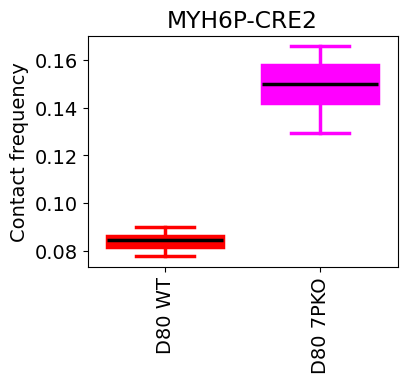

In [17]:
i1,i2 = [13,28]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ranksums

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_all[:,i1,i2]
box_X = ax.boxplot(X, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_all[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between D80 7PKO and D80 WT: {pval:.2e}")

plt.xlim([-0.1,0.3])
plt.xticks([0,0.2],['D80 WT','D80 7PKO'],rotation='vertical')
plt.title('MYH6P-CRE2')
plt.ylabel("Contact frequency")

plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure47PKO_{i1}_{i2}.pdf", format='pdf', bbox_inches='tight', dpi=600)

Rank-sum p-value between D80 7PKO and D80 WT: 1.33e-22


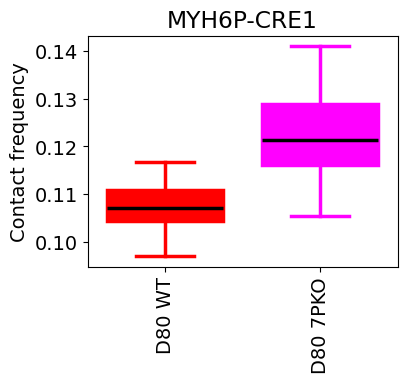

In [18]:
i1,i2 = [13,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ranksums

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_all[:,i1,i2]
box_X = ax.boxplot(X, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_all[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between D80 7PKO and D80 WT: {pval:.2e}")

plt.xlim([-0.1,0.3])
plt.xticks([0,0.2],['D80 WT','D80 7PKO'],rotation='vertical')
plt.title('MYH6P-CRE1')
plt.ylabel("Contact frequency")

plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure47PKO_{i1}_{i2}.pdf", format='pdf', bbox_inches='tight', dpi=600)

Rank-sum p-value between D80 7PKO and D80 WT: 2.52e-34


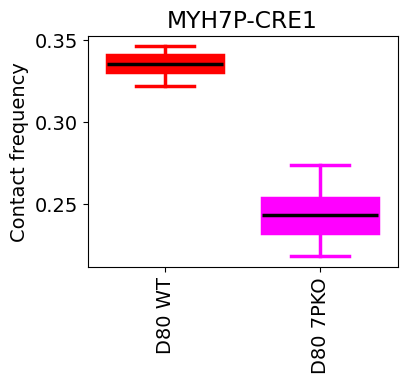

In [19]:
i1,i2 = [27,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ranksums

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_all[:,i1,i2]
box_X = ax.boxplot(X, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_all[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between D80 7PKO and D80 WT: {pval:.2e}")

plt.xlim([-0.1,0.3])
plt.xticks([0,0.2],['D80 WT','D80 7PKO'],rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("Contact frequency")

plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure47PKO_{i1}_{i2}.pdf", format='pdf', bbox_inches='tight', dpi=600)

In [13]:
med_D120 = np.nanmedian(mats_D120,axis=0)
med_D118 = np.nanmedian(mats_D118,axis=0)
med_D104 = np.nanmedian(mats_D104, axis=0)

In [20]:
import numpy as np
from tqdm import tqdm

def get_random_med(mats, iDNA7_, N=100):
    med_7_Cs = []
    for i in tqdm(np.arange(N)):
        # sample with replacement
        iRand = np.random.randint(0, len(iDNA7_), len(iDNA7_))
        # take subset and compute nanmedian along axis=0
        med_7_C = np.nanmedian(mats[iDNA7_[iRand]], axis=0)
        med_7_Cs.append(med_7_C)
    return np.array(med_7_Cs)

In [21]:
mats_D120_med = get_random_med(mats_D120,np.arange(len(mats_D120)),N=100)
mats_D104_med = get_random_med(mats_D104,np.arange(len(mats_D104)),N=100)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:40<00:00,  2.46it/s]


Rank-sum p-value between D80 7PKO and D80 WT: 2.52e-34


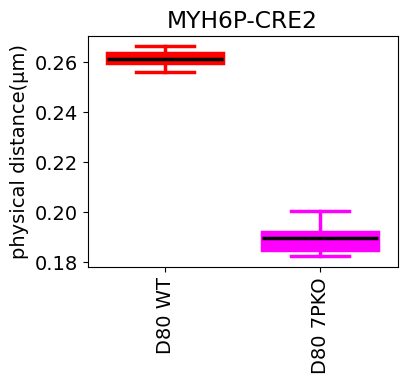

In [22]:
i1,i2 = [13,28]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ranksums

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_med[:,i1,i2]
box_X = ax.boxplot(X, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_med[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between D80 7PKO and D80 WT: {pval:.2e}")

plt.xlim([-0.1,0.3])
plt.xticks([0,0.2],['D80 WT','D80 7PKO'],rotation='vertical')
plt.title('MYH6P-CRE2')
plt.ylabel("physical distance(µm)")

plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure47PKO_{i1}_{i2}_dis.pdf", format='pdf', bbox_inches='tight', dpi=600)

Rank-sum p-value between D80 7PKO and D80 WT: 2.52e-34


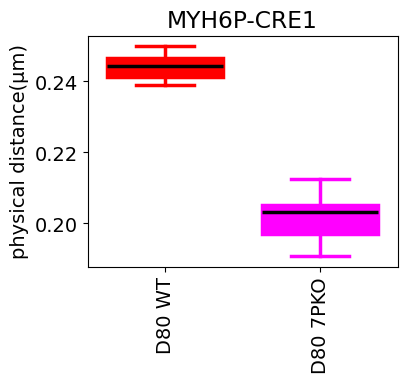

In [23]:
i1,i2 = [13,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ranksums

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_med[:,i1,i2]
box_X = ax.boxplot(X, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_med[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between D80 7PKO and D80 WT: {pval:.2e}")

plt.xlim([-0.1,0.3])
plt.xticks([0,0.2],['D80 WT','D80 7PKO'],rotation='vertical')
plt.title('MYH6P-CRE1')
plt.ylabel("physical distance(µm)")

plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure47PKO_{i1}_{i2}_dis.pdf", format='pdf', bbox_inches='tight', dpi=600)

Rank-sum p-value between D80 7PKO and D80 WT: 2.52e-34


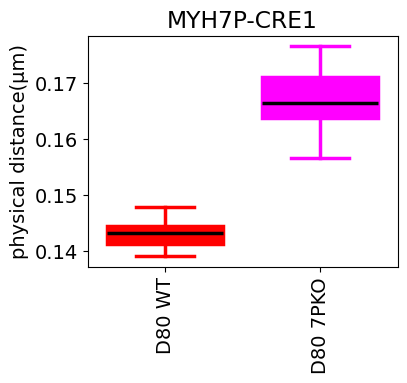

In [24]:
i1,i2 = [27,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ranksums

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_med[:,i1,i2]
box_X = ax.boxplot(X, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_med[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between D80 7PKO and D80 WT: {pval:.2e}")

plt.xlim([-0.1,0.3])
plt.xticks([0,0.2],['D80 WT','D80 7PKO'],rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("physical distance(µm)")

plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure47PKO_{i1}_{i2}_dis.pdf", format='pdf', bbox_inches='tight', dpi=600)

In [25]:
mats_D120_med.shape

(100, 42, 42)

In [14]:
i1,i2 = [13,28]
med_D104[i1, i2], med_D120[i1, i2]

(0.2614989370773324, 0.18905707392868887)

In [15]:
i1,i2 = [13,30]
med_D104[i1, i2], med_D120[i1, i2]

(0.2566477509420142, 0.20770193623627678)

In [16]:
i1,i2 = [27,30]
med_D104[i1, i2], med_D120[i1, i2]

(0.13962762337461407, 0.14906394106221788)

In [33]:
med_D120

array([[0.        , 0.16439932, 0.18190729, ..., 0.32336977, 0.28023937,
        0.30251353],
       [0.16439932, 0.        , 0.08120717, ..., 0.2970504 , 0.31095134,
        0.28028105],
       [0.18190729, 0.08120717, 0.        , ..., 0.28497485, 0.2519589 ,
        0.32142598],
       ...,
       [0.32336977, 0.2970504 , 0.28497485, ..., 0.        , 0.07434285,
        0.08031509],
       [0.28023937, 0.31095134, 0.2519589 , ..., 0.07434285, 0.        ,
        0.08039843],
       [0.30251353, 0.28028105, 0.32142598, ..., 0.08031509, 0.08039843,
        0.        ]])

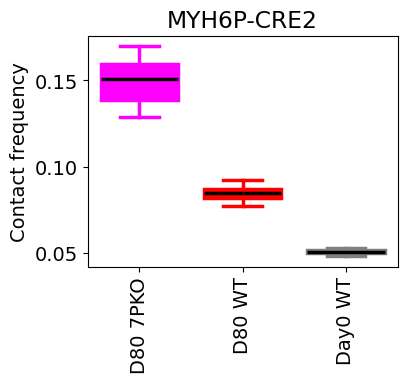

In [38]:
i1,i2 = [13,28]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_all[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_all[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 7PKO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH6P-CRE2')
plt.ylabel("Contact frequency")

plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure47PKO_{i1}_{i2}.pdf", format='pdf', bbox_inches='tight', dpi=600)

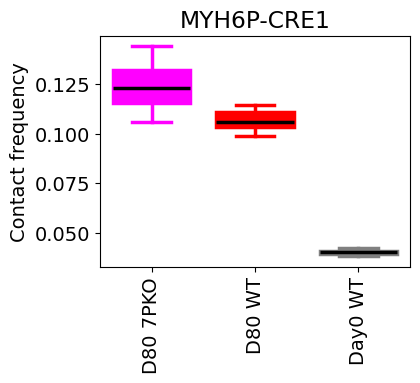

In [35]:
i1,i2 = [13,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_all[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_all[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 7PKO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH6P-CRE1')
plt.ylabel("Contact frequency")

plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure47PKO_{i1}_{i2}.jpg", format='jpg', bbox_inches='tight', dpi = 600)

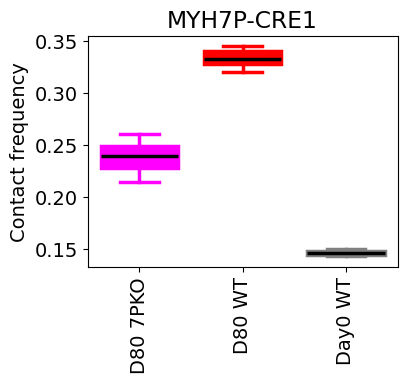

In [36]:
i1,i2 = [27,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))
# X = mats_D103_6[:,i1,i2]
# box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
#                    boxprops=dict(facecolor='red', color='red',linewidth=line_width),
#                    whiskerprops=dict(color='red',linewidth=line_width),
#                    capprops=dict(color='red',linewidth=line_width),
#                    medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

# # Box plot for Y in green
# Y = mats_D103_7[:,i1,i2]
# box_Y = ax.boxplot(Y, positions=[0.2], patch_artist=True, 
#                    boxprops=dict(facecolor='green', color='green',linewidth=line_width),
#                    whiskerprops=dict(color='green',linewidth=line_width),
#                    capprops=dict(color='green',linewidth=line_width),
#                    medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

X = mats_D120_all[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_all[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 7PKO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("Contact frequency")

plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure47PKO_{i1}_{i2}.jpg", format='jpg', bbox_inches='tight', dpi = 600)

Text(0, 0.5, 'Contact frequency')

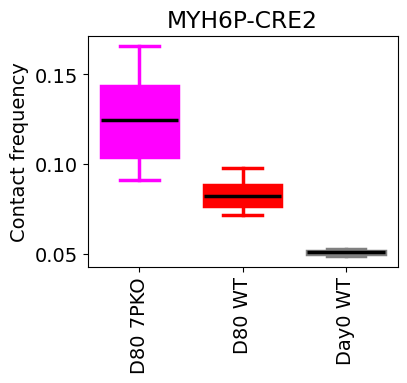

In [117]:
i1,i2 = [13,28]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_m[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_m[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 7PKO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH6P-CRE2')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

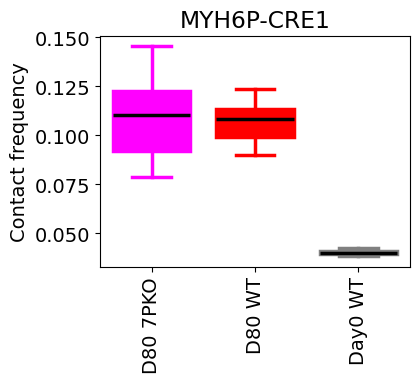

In [118]:
i1,i2 = [13,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_m[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_m[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 7PKO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH6P-CRE1')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

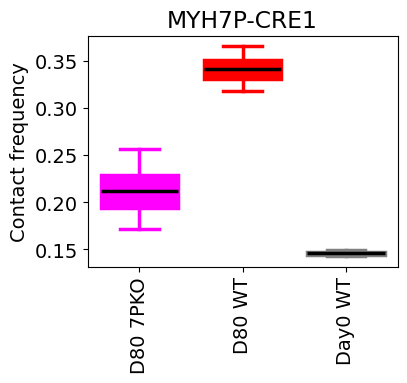

In [119]:
i1,i2 = [27,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_m[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_m[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 7PKO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("Contact frequency")